# MYTIGATE — Debug Pipeline
Step-by-step execution with map output after each module.
Run cells in order. Check each map before proceeding to the next step.

**Fast debug mode:** set `N_SCENARIOS = 50` in config.py before running.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
from shapely.geometry import Polygon
from pathlib import Path

from config import (
    GRID_GPKG, BASELINE_GPKG, BATHY_PATH,
    PRIMARY_HARVEST, HARVEST_MONTHS,
    MOCK_FARM_COORDS_LONLAT, N_SCENARIOS,
    LONGLINE_LENGTH, LONGLINE_SPACING, LONGLINES_PER_SECTION,
)

# Plot settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 8)
WEBMERCATOR = 'EPSG:3857'
UTM32N = 'EPSG:32632'

def add_basemap(ax):
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=7)
    except Exception as e:
        print(f'  Basemap unavailable: {e}')

print('Imports OK')

Imports OK


## Cell 1 — Build Grid

Building / loading 1km UTM32N grid...
[Grid] Building 310 × 378 = 117,180 cells...
[Grid] Built 117,180 cells
[Grid] Loading coastline...
[Grid] Simplifying (70972 polygons, 500m tolerance)...
[Grid] Dissolving...
[Grid] Dissolve done
[Grid] 56,120 land cells identified via sindex
[Grid] 56,120 land cells removed → 61,060 sea cells
[Grid] Saved → c:\Users\garo\OneDrive - Det Kongelige Akademi\AP\03_teaching\0_CiA\2627\SEM1_workshop2\code_claude\data\processed\grid_base.gpkg  (61,060 cells)

--- GRID SUMMARY ---
Cells        : 61,060
CRS          : EPSG:32632
Bounds (UTM) : [ 442000. 6054000.  752000. 6432000.]
Columns      : ['cell_id', 'x_center', 'y_center', 'geometry', 'lon', 'lat']


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


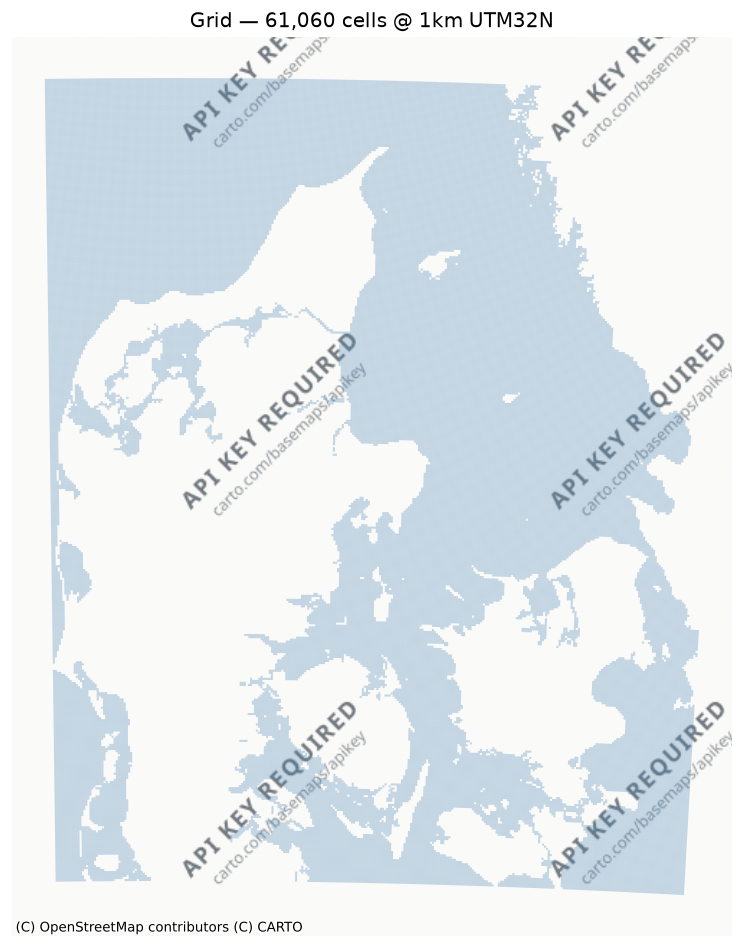

In [2]:
from utils.grid import load_or_build_grid

print('Building / loading 1km UTM32N grid...')
grid = load_or_build_grid()

print(f'\n--- GRID SUMMARY ---')
print(f'Cells        : {len(grid):,}')
print(f'CRS          : {grid.crs}')
print(f'Bounds (UTM) : {grid.total_bounds}')
print(f'Columns      : {list(grid.columns)}')

fig, ax = plt.subplots()
grid.to_crs(WEBMERCATOR).plot(ax=ax, color='steelblue', alpha=0.3, edgecolor='none')
add_basemap(ax)
ax.set_title(f'Grid — {len(grid):,} cells @ 1km UTM32N')
ax.axis('off')
plt.tight_layout()
plt.show()

## Cell 2 — Bathymetry

Sampling EMODnet bathymetry...
  [M1] Sampling bathymetry (61,060 cells)...
  [M1] Bathymetry: 60,939 valid cells

--- BATHYMETRY ---
Valid cells  : 60,939
Min depth    : 0.0 m
Max depth    : 597.6 m
Mean depth   : 43.8 m
Viable (>=4m): 55,450 cells


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


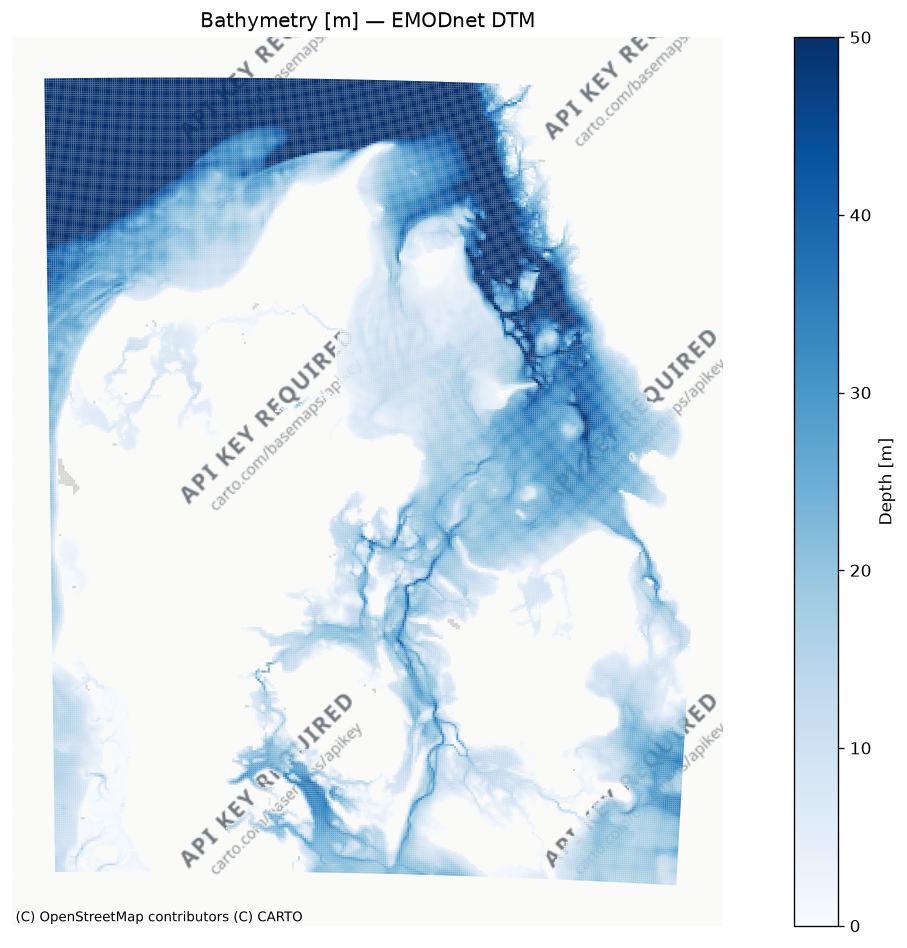

In [4]:
from utils.raster_sampler import sample_bathymetry

print('Sampling EMODnet bathymetry...')
grid = sample_bathymetry(grid, BATHY_PATH)

b = grid['bathymetry_m'].dropna()
print(f'\n--- BATHYMETRY ---')
print(f'Valid cells  : {len(b):,}')
print(f'Min depth    : {b.min():.1f} m')
print(f'Max depth    : {b.max():.1f} m')
print(f'Mean depth   : {b.mean():.1f} m')
print(f'Viable (>=4m): {(b >= 4).sum():,} cells')

fig, ax = plt.subplots()
grid.to_crs(WEBMERCATOR).plot(
    column='bathymetry_m', ax=ax, cmap='Blues',
    legend=True, legend_kwds={'label':'Depth [m]'},
    vmin=0, vmax=50, missing_kwds={'color':'lightgrey'}
)
add_basemap(ax)
ax.set_title('Bathymetry [m] — EMODnet DTM')
ax.axis('off')
plt.tight_layout()
plt.show()

## Cell 3 — Module 1: Temperature

Running Module 1 (baseline — no scenario)...
This may take 15-25 minutes for the full grid.
Tip: interrupt and reload from GRID_GPKG if already computed.

=== Module 1: BASELINE ===
  [M1] Projecting grid centroids to WGS84 (once)...


c:\Users\garo\OneDrive - Det Kongelige Akademi\AP\03_teaching\0_CiA\2627\SEM1_workshop2\code_claude\utils\raster_sampler.py:429: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lons     = grid_wgs.geometry.centroid.x.values
c:\Users\garo\OneDrive - Det Kongelige Akademi\AP\03_teaching\0_CiA\2627\SEM1_workshop2\code_claude\utils\raster_sampler.py:430: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lats     = grid_wgs.geometry.centroid.y.values


  [M1] Sampling Baltic + NWS concurrently: ['temp', 'sal', 'lnchla', 'flow']
    [Baltic] Temp...
    [NWS] Temp...


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\dask\array\numpy_com

    [NWS] Sal...
    [Baltic] Sal...


...

c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


    [Baltic] Flow...


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the

  [M1] Cached → grid_env_temp.gpkg  (24 columns)
  [M1] Cached → grid_env_sal.gpkg  (24 columns)
  [M1] Cached → grid_env_chla.gpkg  (24 columns)
  [M1] Cached → grid_env_flow.gpkg  (36 columns)
  [M1] Temp   July: 52,708 valid cells
  [M1] Sal    July: 52,708 valid cells
  [M1] ChlA   July: 52,708 valid cells
  [M1] Flow   July: 52,705 valid cells

--- MODULE 1: TEMPERATURE ---
  January: min=0.8°C  max=6.5°C  mean=4.1°C  valid=52,708
  July: min=15.4°C  max=20.5°C  mean=17.1°C  valid=52,708


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


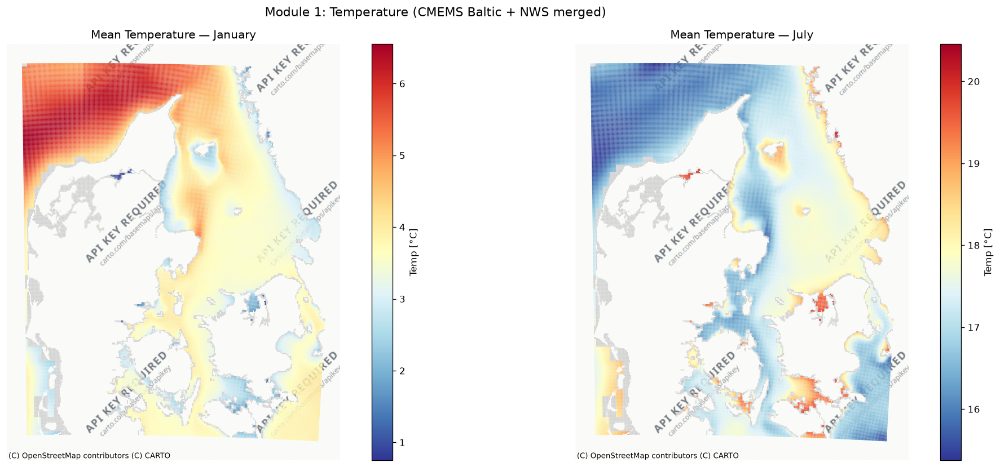

In [5]:
from utils.raster_sampler import run_module1

print('Running Module 1 (baseline — no scenario)...')
print('This may take 15-25 minutes for the full grid.')
print('Tip: interrupt and reload from GRID_GPKG if already computed.')
grid = run_module1(grid, delta_temp=0, delta_sal=0, chla_mult=1.0)

print(f'\n--- MODULE 1: TEMPERATURE ---')
for month, label in [(1,'January'), (7,'July')]:
    col = f'temp_mean_{month:02d}'
    t = grid[col].dropna()
    print(f'  {label}: min={t.min():.1f}°C  max={t.max():.1f}°C  mean={t.mean():.1f}°C  valid={len(t):,}')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (month, label) in zip(axes, [(1,'January'), (7,'July')]):
    col = f'temp_mean_{month:02d}'
    grid.to_crs(WEBMERCATOR).plot(
        column=col, ax=ax, cmap='RdYlBu_r',
        legend=True, legend_kwds={'label':'Temp [°C]'},
        missing_kwds={'color':'lightgrey'}
    )
    add_basemap(ax)
    ax.set_title(f'Mean Temperature — {label}')
    ax.axis('off')
plt.suptitle('Module 1: Temperature (CMEMS Baltic + NWS merged)', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 4 — Module 1: Salinity

--- MODULE 1: SALINITY ---
  January: min=0.1 psu  max=34.5 psu  mean=23.2 psu  valid=52,708
    Cells below 16.2 psu (fS penalty): 9,689
  July: min=0.1 psu  max=33.9 psu  mean=21.8 psu  valid=52,708
    Cells below 16.2 psu (fS penalty): 14,275


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


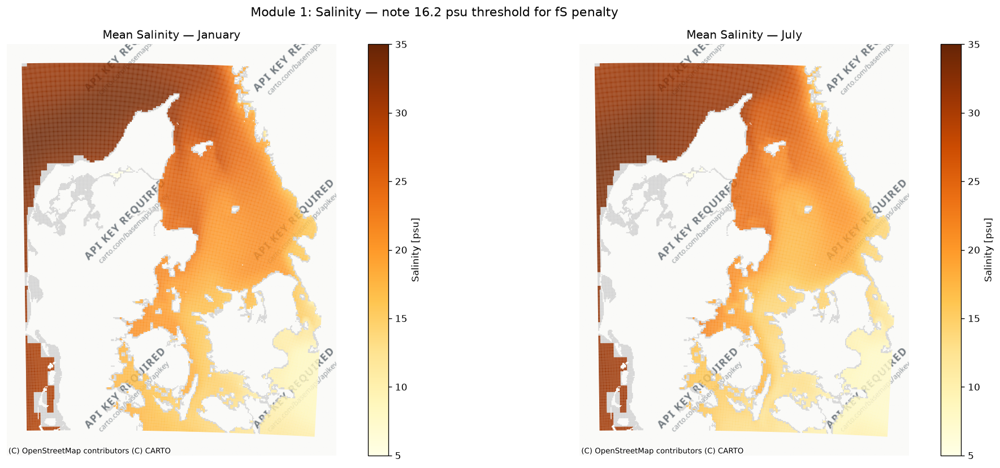

In [6]:
print('--- MODULE 1: SALINITY ---')
for month, label in [(1,'January'), (7,'July')]:
    col = f'sal_mean_{month:02d}'
    s = grid[col].dropna()
    print(f'  {label}: min={s.min():.1f} psu  max={s.max():.1f} psu  mean={s.mean():.1f} psu  valid={len(s):,}')
    print(f'    Cells below 16.2 psu (fS penalty): {(s < 16.2).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (month, label) in zip(axes, [(1,'January'), (7,'July')]):
    col = f'sal_mean_{month:02d}'
    grid.to_crs(WEBMERCATOR).plot(
        column=col, ax=ax, cmap='YlOrBr',
        legend=True, legend_kwds={'label':'Salinity [psu]'},
        vmin=5, vmax=35,
        missing_kwds={'color':'lightgrey'}
    )
    add_basemap(ax)
    ax.set_title(f'Mean Salinity — {label}')
    ax.axis('off')
plt.suptitle('Module 1: Salinity — note 16.2 psu threshold for fS penalty', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 5 — Module 1: Chlorophyll-a

--- MODULE 1: CHLOROPHYLL-A ---
  January: ChlA min=0.02  max=3.70  mean=0.98 μg/L  valid=52,708
  July: ChlA min=0.24  max=17.31  mean=1.30 μg/L  valid=52,708


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

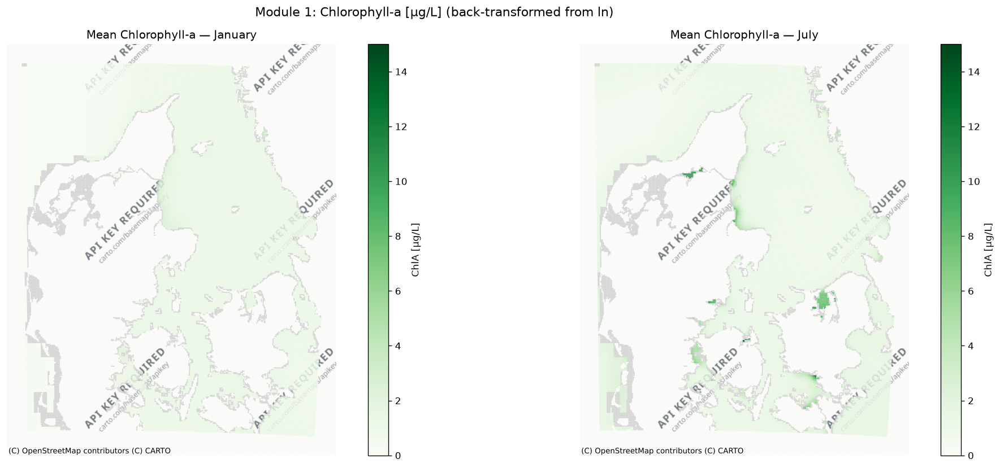

In [7]:
print('--- MODULE 1: CHLOROPHYLL-A ---')
for month, label in [(1,'January'), (7,'July')]:
    col = f'lnchla_mean_{month:02d}'
    lc = grid[col].dropna()
    chla = np.exp(lc)
    print(f'  {label}: ChlA min={chla.min():.2f}  max={chla.max():.2f}  mean={chla.mean():.2f} μg/L  valid={len(chla):,}')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (month, label) in zip(axes, [(1,'January'), (7,'July')]):
    col = f'lnchla_mean_{month:02d}'
    chla_col = f'chla_display_{month:02d}'
    grid[chla_col] = np.exp(grid[col])
    grid.to_crs(WEBMERCATOR).plot(
        column=chla_col, ax=ax, cmap='Greens',
        legend=True, legend_kwds={'label':'ChlA [μg/L]'},
        vmin=0, vmax=15,
        missing_kwds={'color':'lightgrey'}
    )
    add_basemap(ax)
    ax.set_title(f'Mean Chlorophyll-a — {label}')
    ax.axis('off')
plt.suptitle('Module 1: Chlorophyll-a [μg/L] (back-transformed from ln)', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 6 — Module 1: Flow velocity

--- MODULE 1: FLOW VELOCITY ---
  July: min=0.0001  max=0.3709  mean=0.0997 m/s  valid=52,705
  November: min=0.0000  max=0.3956  mean=0.0946 m/s  valid=52,705


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


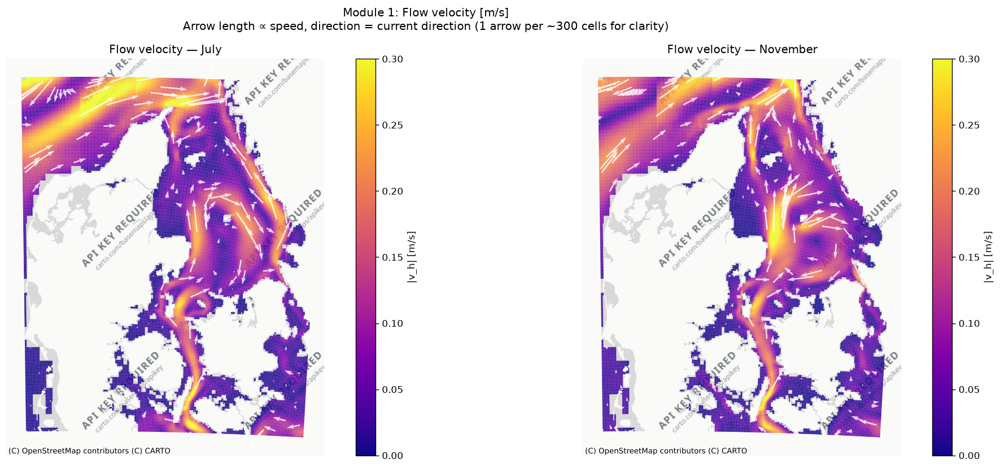

In [8]:
print('--- MODULE 1: FLOW VELOCITY ---')
for month, label in [(7,'July'), (11,'November')]:
    col = f'vh_{month:02d}'
    v = grid[col].dropna()
    print(f'  {label}: min={v.min():.4f}  max={v.max():.4f}  mean={v.mean():.4f} m/s  valid={len(v):,}')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (month, label) in zip(axes, [(7,'July'), (11,'November')]):
    mk = f'{month:02d}'

    # Plot flow speed
    grid.to_crs(WEBMERCATOR).plot(
        column=f'vh_{mk}', ax=ax, cmap='plasma',
        legend=True, legend_kwds={'label':'|v_h| [m/s]'},
        vmin=0, vmax=0.3,
        missing_kwds={'color':'lightgrey'}
    )

    # Save axes bounds before quiver
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # Direction arrows — subsample for display only (every 300th cell)
    # Arrow length proportional to velocity magnitude (correct behaviour)
    # Full uo/vo per cell is still used in Module 12 farm computation
    sample = grid[grid[f'uo_{mk}'].notna()].iloc[::300].to_crs(WEBMERCATOR)
    if not sample.empty:
        cx = sample.geometry.centroid.x.values
        cy = sample.geometry.centroid.y.values
        uo = sample[f'uo_{mk}'].values
        vo = sample[f'vo_{mk}'].values
        ax.quiver(cx, cy, uo, vo, color='white', alpha=0.8)

    # Restore bounds — quiver can expand axes
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    add_basemap(ax)
    ax.set_title(f'Flow velocity — {label}')
    ax.axis('off')

plt.suptitle('Module 1: Flow velocity [m/s]\nArrow length ∝ speed, direction = current direction (1 arrow per ~300 cells for clarity)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#DEBUG
# # Check flow velocity columns
# flow_cols = [c for c in grid.columns if c.startswith('vh_') or c.startswith('uo_') or c.startswith('vo_')]
# print("Flow columns found:", flow_cols)
# print()

# # Check values
# if 'vh_07' in grid.columns:
#     print("vh_07 stats:")
#     print(f"  NaN count : {grid['vh_07'].isna().sum():,} / {len(grid):,}")
#     print(f"  Zero count: {(grid['vh_07'] == 0).sum():,}")
#     print(f"  Min       : {grid['vh_07'].min():.4f}")
#     print(f"  Max       : {grid['vh_07'].max():.4f}")
#     print(f"  Mean      : {grid['vh_07'].mean():.4f}")
# else:
#     print("vh_07 not found — flow sampling failed")
#     print("All columns:", list(grid.columns))

## Test just the choropleth without arrows or basemap
# fig, ax = plt.subplots(figsize=(10, 8))
# grid.to_crs(WEBMERCATOR).plot(
#     column='vh_07', ax=ax, cmap='plasma',
#     legend=True, vmin=0, vmax=0.3,
#     missing_kwds={'color': 'lightgrey'}
# )
# ax.set_title('Flow velocity July — no basemap, no arrows')
# plt.show()


# # Debug quiver scaling
# fig, ax = plt.subplots(figsize=(10, 8))

# # Plot the base map first
# grid.to_crs(WEBMERCATOR).plot(
#     column='vh_07', ax=ax, cmap='plasma',
#     legend=True, vmin=0, vmax=0.3,
#     missing_kwds={'color':'lightgrey'}
# )

# # Check axes bounds BEFORE adding arrows
# xmin, xmax = ax.get_xlim()
# ymin, ymax = ax.get_ylim()
# print(f'Axes bounds (WebMercator metres):')
# print(f'  X: {xmin:.0f} to {xmax:.0f}  range={xmax-xmin:.0f}m')
# print(f'  Y: {ymin:.0f} to {ymax:.0f}  range={ymax-ymin:.0f}m')

# # Sample a few arrows
# sample = grid[grid['uo_07'].notna()].iloc[::500].to_crs(WEBMERCATOR)
# cx = sample.geometry.centroid.x.values
# cy = sample.geometry.centroid.y.values
# uo = sample['uo_07'].values
# vo = sample['vo_07'].values
# print(f'\nArrow data:')
# print(f'  n arrows: {len(cx)}')
# print(f'  uo range: {uo.min():.4f} to {uo.max():.4f}')
# print(f'  vo range: {vo.min():.4f} to {vo.max():.4f}')

# plt.show()


##arrow size
# fig, ax = plt.subplots(figsize=(10, 8))

# grid.to_crs(WEBMERCATOR).plot(
#     column='vh_07', ax=ax, cmap='plasma',
#     legend=True, vmin=0, vmax=0.3,
#     missing_kwds={'color':'lightgrey'}
# )

# sample = grid[grid['uo_07'].notna()].iloc[::500].to_crs(WEBMERCATOR)
# cx = sample.geometry.centroid.x.values
# cy = sample.geometry.centroid.y.values
# uo = sample['uo_07'].values
# vo = sample['vo_07'].values

# # Fix axes bounds before quiver
# xmin, xmax = ax.get_xlim()
# ymin, ymax = ax.get_ylim()

# ax.quiver(cx, cy, uo, vo, color='white', alpha=0.8)

# # Restore bounds — quiver can expand them
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)

# plt.show()

In [ ]:
#####DEBUG
#grid.to_file("output_test.geojson", driver="GeoJSON")


## Cell 7 — Module 11: Exclusion layers

Running Module 11 (exclusions and conflict layers)...

=== Module 11: Exclusions and Conflict Layers ===
  [M11] excl_shallow: 5,610 cells
  [M11] Running polygon exclusion layers in parallel...


  Exclusion layers:  50%|█████     | 2/4 [00:00<00:00,  5.38it/s]

  [M11] excl_military       : 2,946 cells
  [M11] excl_wind_farms     : 4,929 cells


  Exclusion layers:  75%|███████▌  | 3/4 [00:01<00:00,  2.05it/s]

  [M11] excl_pipelines      : 255 cells


  Exclusion layers: 100%|██████████| 4/4 [00:02<00:00,  1.38it/s]

  [M11] excl_mpa            : 13,458 cells
  [M11] excl_cables           : 1,160 cells

  [M11] Total excluded: 24,916 (40.8%)
  [M11] Available:      36,144 cells

  [M11] Computing conflict gradients...
  [M11] Shipping: point-sampling 7 rasters at centroids...



c:\Users\garo\OneDrive - Det Kongelige Akademi\AP\03_teaching\0_CiA\2627\SEM1_workshop2\code_claude\model\module11_exclusions.py:121: RuntimeWarning: Mean of empty slice
  avg = np.nanmean(arrays, axis=0)


  [M11] Conflict score: 0.000 – 0.659

--- MODULE 11: EXCLUSIONS ---
  excl_shallow             : 5,610 cells
  excl_military            : 2,946 cells
  excl_wind_farms          : 4,929 cells
  excl_pipelines           : 255 cells
  excl_mpa                 : 13,458 cells
  excl_cables              : 1,160 cells
  excluded (any)           : 24,916 cells  (40.8%)


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


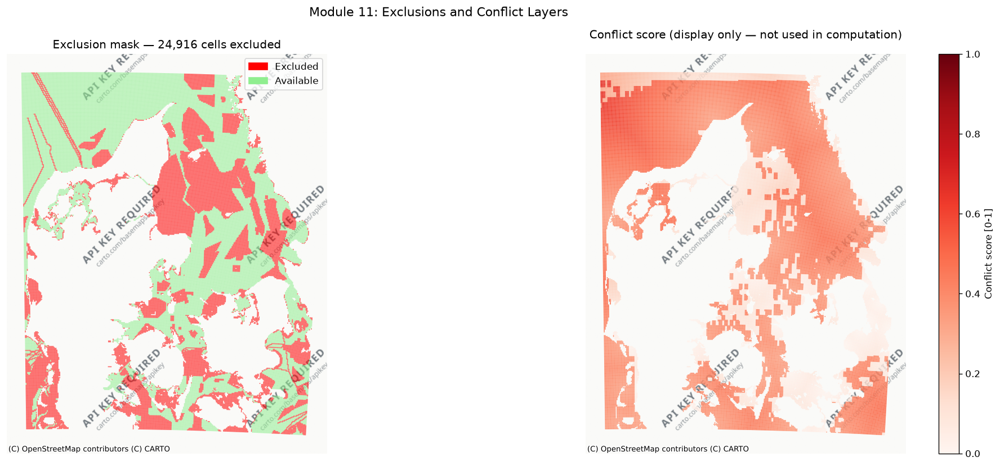

In [9]:
##force reimport to debug
# import inspect
# import model.module11_exclusions as m11
# import importlib
# importlib.reload(m11)
# lines = inspect.getsource(m11.run_module11)
# # Find the harbours section
# idx = lines.find('conflict_harbours')
# print(lines[idx-200:idx+300])

from model.module11_exclusions import run_module11

print('Running Module 11 (exclusions and conflict layers)...')
grid = run_module11(grid)

excl_cols = [c for c in grid.columns if c.startswith('excl_') and c != 'excluded']
print(f'\n--- MODULE 11: EXCLUSIONS ---')
for col in excl_cols:
    print(f'  {col:25s}: {grid[col].sum():,} cells')
print(f'  {"excluded (any)":25s}: {grid["excluded"].sum():,} cells  ({100*grid["excluded"].mean():.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Exclusion map
ax = axes[0]
colors = grid['excluded'].map({True: 'red', False: 'lightgreen'})
grid.to_crs(WEBMERCATOR).plot(color=colors, ax=ax, alpha=0.6, edgecolor='none')
add_basemap(ax)
patches = [mpatches.Patch(color='red', label='Excluded'), mpatches.Patch(color='lightgreen', label='Available')]
ax.legend(handles=patches)
ax.set_title(f'Exclusion mask — {grid["excluded"].sum():,} cells excluded')
ax.axis('off')

# Conflict score map
ax = axes[1]
grid.to_crs(WEBMERCATOR).plot(
    column='conflict_score', ax=ax, cmap='Reds',
    legend=True, legend_kwds={'label':'Conflict score [0-1]'},
    vmin=0, vmax=1,
    missing_kwds={'color':'lightgrey'}
)
add_basemap(ax)
ax.set_title('Conflict score (display only — not used in computation)')
ax.axis('off')

plt.suptitle('Module 11: Exclusions and Conflict Layers', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
## DEBUG FOR GRASSHOPPER

# from config import MPA_SHP, MILITARY_SHP, WINDFARMS_SHP, PIPELINES_SHP, CABLES_DIRS
# import geopandas as gpd

# exclusion_zones = gpd.GeoDataFrame(
#     {'layer': ['mpa','military','wind_farms','pipelines','power_cables','telecom_cables']},
#     geometry=[gpd.read_file(p).to_crs('EPSG:32632').union_all() 
#               for p in [MPA_SHP, MILITARY_SHP, WINDFARMS_SHP, PIPELINES_SHP, 
#                         CABLES_DIRS[0], CABLES_DIRS[1]]],
#     crs='EPSG:32632'
# )
# exclusion_zones.to_file("exclusion_zones.gpkg", driver="GPKG")

## Cell 8 — Module 12: Farm discretisation (mock polygon)

Running Module 12 (farm discretisation) on mock polygon...
Mock polygon coordinates (lon, lat):
  lon=9.789648, lat=55.570628
  lon=9.809943, lat=55.570340
  lon=9.808489, lat=55.561383
  lon=9.789311, lat=55.561235

=== Module 12: Farm Discretisation ===
  [M12] Polygon area: 127.1 ha
  [M12] Cells inside polygon: 6
  [M12] After exclusion: 6 (0 excluded)
  [M12] Viable cells (depth ≥4.0m): 6
  [M12] Current: uo=-0.0002 vo=0.0006 m/s  orientation=344.9°
  [M12] D_short=240m  D_long=200m  sections=125  area=600.0ha
  [M12] l_col mean: 5035714 m  rdep range: 2.0–2.0 m

--- MODULE 12: FARM GEOMETRY ---
  Grid cells inside polygon: 6
  Sections that fit        : 125
  D_short (current dir)    : 240 m
  D_long (across current)  : 200 m
  Farm area                : 600.0 ha
  Mean l_col               : 5035714 m
  Orientation from north   : 344.9°
  Current uo               : -0.0002 m/s
  Current vo               : 0.0006 m/s
  Mean flow speed          : 0.0006 m/s


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


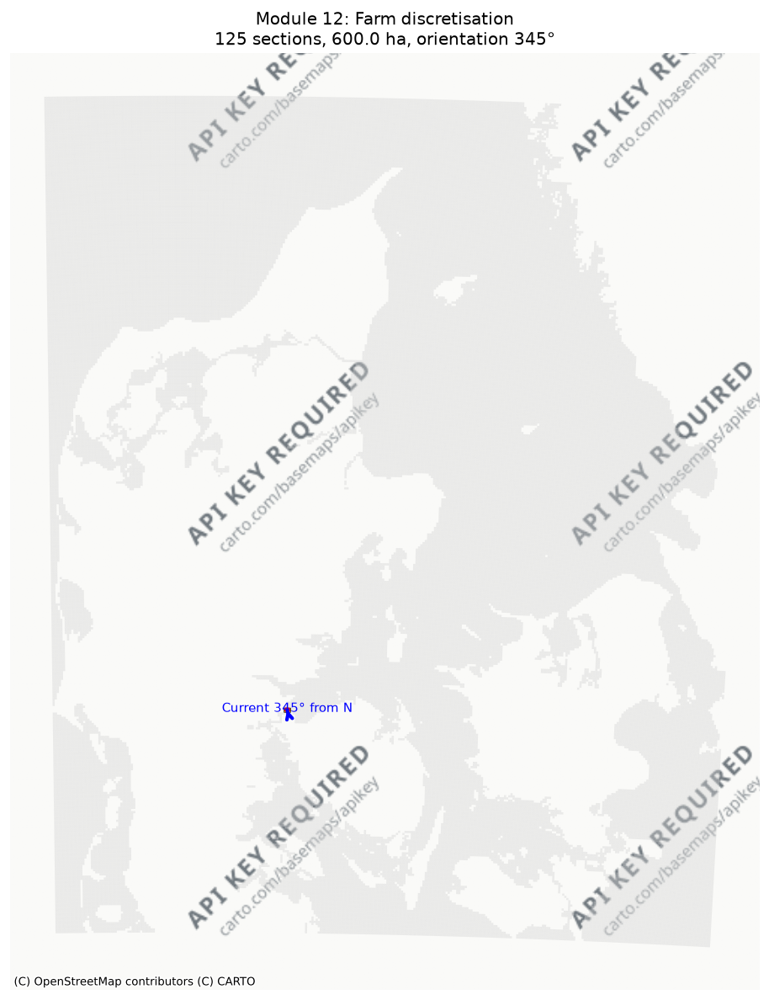

In [10]:
from model.module12_farm import discretise_farm, lonlat_to_utm

print('Running Module 12 (farm discretisation) on mock polygon...')
print(f'Mock polygon coordinates (lon, lat):')
for coord in MOCK_FARM_COORDS_LONLAT:
    print(f'  lon={coord[0]:.6f}, lat={coord[1]:.6f}')

farm_result = discretise_farm(
    polygon_lonlat        = MOCK_FARM_COORDS_LONLAT,
    grid                  = grid,
    longline_length       = LONGLINE_LENGTH,
    longline_spacing      = LONGLINE_SPACING,
    longlines_per_section = LONGLINES_PER_SECTION,
    max_rdep              = 2.0,
    iloop                 = 0.7,
)

print(f'\n--- MODULE 12: FARM GEOMETRY ---')
print(f'  Grid cells inside polygon: {len(farm_result["farm_cells"])}')
print(f'  Sections that fit        : {farm_result["n_sections"]}')
print(f'  D_short (current dir)    : {farm_result["D_short"]} m')
print(f'  D_long (across current)  : {farm_result["D_long"]} m')
print(f'  Farm area                : {farm_result["farm_area_m2"]/1e4:.1f} ha')
print(f'  Mean l_col               : {farm_result["l_col"]:.0f} m')
print(f'  Orientation from north   : {farm_result["orientation_deg"]:.1f}°')
print(f'  Current uo               : {farm_result["uo"]:.4f} m/s')
print(f'  Current vo               : {farm_result["vo"]:.4f} m/s')
print(f'  Mean flow speed          : {farm_result["vh_mean"]:.4f} m/s')

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

# Background: all grid cells
grid.to_crs(WEBMERCATOR).plot(ax=ax, color='lightgrey', alpha=0.4, edgecolor='none')

# Farm cells
if not farm_result['farm_cells'].empty:
    farm_result['farm_cells'].to_crs(WEBMERCATOR).plot(
        ax=ax, color='orange', alpha=0.8, edgecolor='black', linewidth=0.5
    )

# Polygon outline
poly_gdf = gpd.GeoDataFrame(geometry=[farm_result['polygon_utm']], crs='EPSG:32632')
poly_gdf.to_crs(WEBMERCATOR).boundary.plot(ax=ax, color='red', linewidth=2)

# Current direction arrow at centroid
centroid = farm_result['polygon_utm'].centroid
centroid_wm = gpd.GeoSeries([centroid], crs='EPSG:32632').to_crs(WEBMERCATOR)
cx, cy = centroid_wm.iloc[0].x, centroid_wm.iloc[0].y
scale = 3000
ax.annotate('', 
    xy=(cx + farm_result['uo']*scale*100, cy + farm_result['vo']*scale*100),
    xytext=(cx, cy),
    arrowprops=dict(arrowstyle='->', color='blue', lw=2.5)
)
ax.text(cx, cy - 1500, f"Current {farm_result['orientation_deg']:.0f}° from N",
        ha='center', color='blue', fontsize=9)

add_basemap(ax)
ax.set_title(f'Module 12: Farm discretisation\n'
             f'{farm_result["n_sections"]} sections, {farm_result["farm_area_m2"]/1e4:.1f} ha, '
             f'orientation {farm_result["orientation_deg"]:.0f}°')
ax.axis('off')
plt.tight_layout()
plt.show()

## Cell 9 — Module 2: Mussel growth

Running Module 2 (mussel growth, 50 MC scenarios)...
NOTE: set N_MC=500 for final run

=== Module 2: Mussel Growth (50 sc, 13 workers) ===


  Harvest months (parallel): 100%|██████████| 5/5 [00:38<00:00,  7.73s/it]


  [M2] 08: max=0.094  mean=0.028 gDW  viable=61,060
  [M2] 09: max=0.264  mean=0.080 gDW  viable=61,060
  [M2] 10: max=0.476  mean=0.153 gDW  viable=61,060
  [M2] 11: max=0.655  mean=0.229 gDW  viable=61,060
  [M2] 12: max=0.739  mean=0.291 gDW  viable=61,060

--- MODULE 2: MUSSEL BIOMASS (November harvest) ---
  p05 (bad year): min=0.038  max=0.551  mean=0.195 gDW
  p50 (avg year): min=0.048  max=0.655  mean=0.229 gDW
  p95 (good year): min=0.057  max=0.770  mean=0.265 gDW
  Paper top 10% range: 0.38–0.71 gDW (validate against this)


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) fo

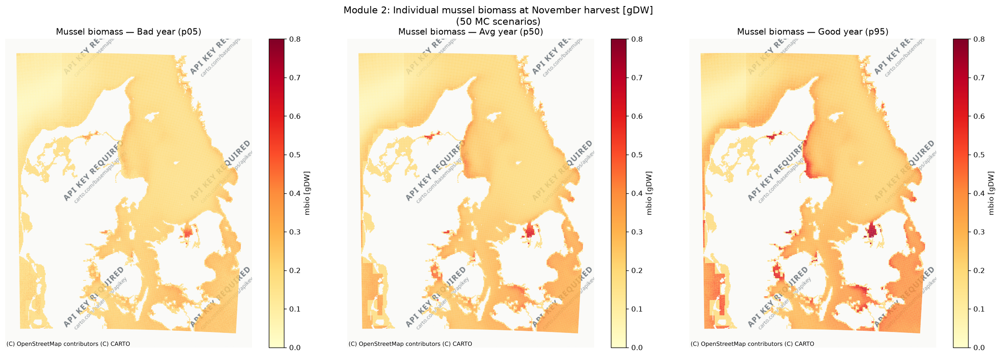

In [11]:
from model.growth import run_module2

N_MC = 50  # Use 50 for debug, 500 for full run
print(f'Running Module 2 (mussel growth, {N_MC} MC scenarios)...')
print('NOTE: set N_MC=500 for final run')

grid = run_module2(grid, n_scenarios=N_MC)

print(f'\n--- MODULE 2: MUSSEL BIOMASS (November harvest) ---')
m = f'{PRIMARY_HARVEST:02d}'
for pct, col in [('p05 (bad year)', f'mbio_p05_{m}'),
                  ('p50 (avg year)', f'mbio_p50_{m}'),
                  ('p95 (good year)',f'mbio_p95_{m}')]:
    v = grid[col].dropna()
    print(f'  {pct}: min={v.min():.3f}  max={v.max():.3f}  mean={v[v>0].mean():.3f} gDW')
print(f'  Paper top 10% range: 0.38–0.71 gDW (validate against this)')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (label, col, vmax) in zip(axes, [
    ('Bad year (p05)',  f'mbio_p05_{m}', 0.8),
    ('Avg year (p50)',  f'mbio_p50_{m}', 0.8),
    ('Good year (p95)', f'mbio_p95_{m}', 0.8),
]):
    grid.to_crs(WEBMERCATOR).plot(
        column=col, ax=ax, cmap='YlOrRd',
        legend=True, legend_kwds={'label':'mbio [gDW]'},
        vmin=0, vmax=vmax,
        missing_kwds={'color':'lightgrey'}
    )
    add_basemap(ax)
    ax.set_title(f'Mussel biomass — {label}')
    ax.axis('off')
plt.suptitle(f'Module 2: Individual mussel biomass at November harvest [gDW]\n({N_MC} MC scenarios)', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 10 — Module 3: Farm upscaling

Running Module 3 (farm upscaling)...
Computing rdep from bathymetry (baseline mode, max_rdep=2m)...

=== Module 3: Farm Upscaling ===
  [M3] Computed lcol_m from rdep (3 sections)
  [M3] 08: max=9.8  mean=6.4 tN  viable=55,450
  [M3] 09: max=13.8  mean=9.1 tN  viable=55,450
  [M3] 10: max=16.8  mean=11.3 tN  viable=55,450
  [M3] 11: max=18.6  mean=13.0 tN  viable=55,450
  [M3] 12: max=19.4  mean=14.0 tN  viable=55,450

--- MODULE 3: FARM OUTPUTS (November harvest) ---
  N-reduction    : max=18.65  mean=12.96  viable=55,450 [tN/farm]
  P-reduction    : max=1.07  mean=0.74  viable=55,450 [tP/farm]
  Harvest FW     : max=1289.18  mean=895.90  viable=55,450 [tWW/farm]
  N/ha           : max=1.29  mean=0.90  viable=55,450 [tN/ha]
  Paper N_red top 10%: 9.2–23.7 tN (2-2_0.7 farm) — validate against this


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) fo

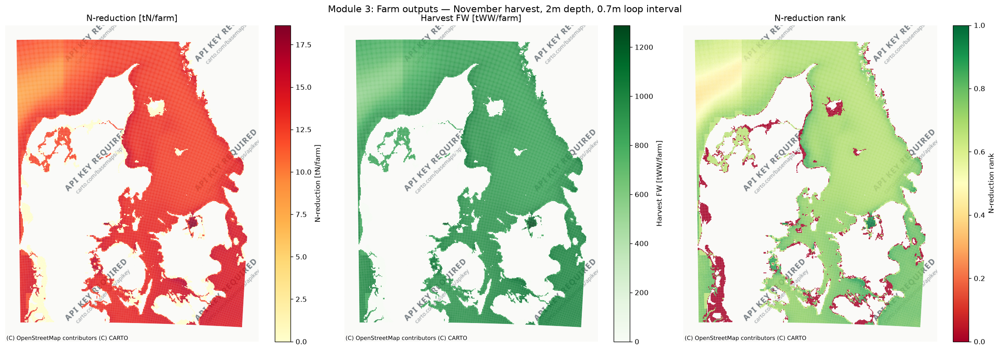

In [12]:
from model.growth import run_module3
import numpy as np

print('Running Module 3 (farm upscaling)...')
print('Computing rdep from bathymetry (baseline mode, max_rdep=2m)...')

bathy = grid['bathymetry_m'].fillna(0).values
max_rdep = 2.0
rdep = np.where(bathy - 2 <= max_rdep, np.maximum(bathy-2, 0), max_rdep)
rdep = np.where(bathy >= 4, rdep, 0.0)
grid['rdep'] = rdep

grid = run_module3(grid)

print(f'\n--- MODULE 3: FARM OUTPUTS (November harvest) ---')
m = f'{PRIMARY_HARVEST:02d}'
for label, col, unit in [
    ('N-reduction', f'N_red_{m}', 'tN/farm'),
    ('P-reduction', f'P_red_{m}', 'tP/farm'),
    ('Harvest FW',  f'harvest_WW_{m}', 'tWW/farm'),
    ('N/ha',        f'N_red_ha_{m}', 'tN/ha'),
]:
    if col in grid.columns:
        v = grid[col]
        print(f'  {label:15s}: max={v.max():.2f}  mean={v[v>0].mean():.2f}  viable={(v>0).sum():,} [{unit}]')
print(f'  Paper N_red top 10%: 9.2–23.7 tN (2-2_0.7 farm) — validate against this')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (label, col, cmap, vmax) in zip(axes, [
    ('N-reduction [tN/farm]', f'N_red_{m}', 'YlOrRd', None),
    ('Harvest FW [tWW/farm]', f'harvest_WW_{m}', 'Greens', None),
    ('N-reduction rank',     f'N_red_{m}_pct', 'RdYlGn', 1.0),
]):
    if col not in grid.columns:
        ax.set_title(f'{label} — not available')
        continue
    kw = dict(vmin=0, vmax=vmax) if vmax else {}
    grid.to_crs(WEBMERCATOR).plot(
        column=col, ax=ax, cmap=cmap,
        legend=True, legend_kwds={'label': label},
        missing_kwds={'color':'lightgrey'}, **kw
    )
    add_basemap(ax)
    ax.set_title(f'{label}')
    ax.axis('off')
plt.suptitle('Module 3: Farm outputs — November harvest, 2m depth, 0.7m loop interval', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 11 — Module 4: Food limitation

Running Module 4 (food limitation check)...

=== Module 4: Food Limitation ===
  [M4] D_short=240m  rho_col=0.20982
  [M4] Building 5 vectorised LUTs...


  M4 months: 100%|██████████| 5/5 [00:00<00:00, 138.78it/s]


  [M4] 07: OK=8,741  warn=42,251  median_vh_crit=0.3194
  [M4] 08: OK=10,254  warn=40,738  median_vh_crit=0.2969
  [M4] 09: OK=23,530  warn=27,462  median_vh_crit=0.2033
  [M4] 10: OK=26,763  warn=24,229  median_vh_crit=0.1242
  [M4] 11: OK=34,059  warn=16,933  median_vh_crit=0.0901

--- MODULE 4: FOOD LIMITATION ---
  Month 07: OK=8,741  warning=42,251  mean_ratio=0.28
  Month 09: OK=23,530  warning=27,462  mean_ratio=0.52
  Month 11: OK=34,059  warning=16,933  mean_ratio=0.95
  food_ok (majority months): 27,887 cells
  NOTE: food limitation is informational only — not used to filter results


c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\garo\AppData\Local\miniconda3\envs\mapping\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


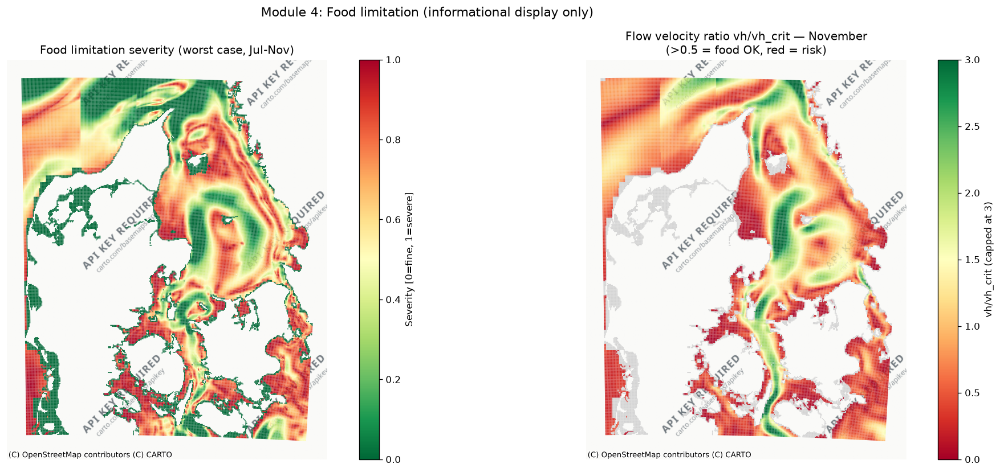

In [13]:
from model.growth import run_module4

print('Running Module 4 (food limitation check)...')
grid = run_module4(grid)

print(f'\n--- MODULE 4: FOOD LIMITATION ---')
for month in [7, 9, 11]:
    mk = f'{month:02d}'
    if f'vh_ratio_{mk}' in grid.columns:
        vr = grid[f'vh_ratio_{mk}'].dropna()
        ok = (vr >= 0.5).sum()
        warn = (vr < 0.5).sum()
        print(f'  Month {mk}: OK={ok:,}  warning={warn:,}  mean_ratio={vr.mean():.2f}')
print(f'  food_ok (majority months): {grid["food_ok"].sum():,} cells')
print(f'  NOTE: food limitation is informational only — not used to filter results')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
grid.to_crs(WEBMERCATOR).plot(
    column='food_limitation_severity', ax=ax, cmap='RdYlGn_r',
    legend=True, legend_kwds={'label':'Severity [0=fine, 1=severe]'},
    vmin=0, vmax=1, missing_kwds={'color':'lightgrey'}
)
add_basemap(ax)
ax.set_title('Food limitation severity (worst case, Jul-Nov)')
ax.axis('off')

ax = axes[1]
if 'vh_ratio_11' in grid.columns:
    plot_data = grid.copy()
    plot_data['vh_ratio_capped'] = grid['vh_ratio_11'].clip(0, 3)
    plot_data.to_crs(WEBMERCATOR).plot(
        column='vh_ratio_capped', ax=ax, cmap='RdYlGn',
        legend=True, legend_kwds={'label':'vh/vh_crit (capped at 3)'},
        vmin=0, vmax=3, missing_kwds={'color':'lightgrey'}
    )
    add_basemap(ax)
    ax.set_title('Flow velocity ratio vh/vh_crit — November\n(>0.5 = food OK, red = risk)')
    ax.axis('off')

plt.suptitle('Module 4: Food limitation (informational display only)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
""" # Debug Module 4 outputs
import numpy as np

print("=== Module 4 Debug ===")
print(f"Total cells: {len(grid):,}")
print(f"Viable cells (rdep>0 & lcol>0): {((grid['rdep']>0) & (grid['lcol_m']>0)).sum():,}")
print()

# Check vh_ratio for November
if 'vh_ratio_11' in grid.columns:
    vr = grid['vh_ratio_11']
    print("vh_ratio_11:")
    print(f"  NaN    : {vr.isna().sum():,}")
    print(f"  Inf    : {np.isinf(vr.fillna(0)).sum():,}")
    print(f"  Zero   : {(vr==0).sum():,}")
    print(f"  <0.5   : {(vr<0.5).sum():,}")
    print(f"  0.5-2  : {((vr>=0.5)&(vr<=2)).sum():,}")
    print(f"  >2     : {(vr>2).sum():,}")
    print(f"  Min/Max: {vr.min():.4f} / {vr.max():.4f}")
else:
    print("vh_ratio_11 not found")

print()

# Check vh_crit
if 'vh_crit_11' in grid.columns:
    vc = grid['vh_crit_11'].dropna()
    print("vh_crit_11 (non-NaN):")
    print(f"  Count  : {len(vc):,}")
    print(f"  Min    : {vc.min():.6f} m/s")
    print(f"  Max    : {vc.max():.6f} m/s")
    print(f"  Mean   : {vc.mean():.6f} m/s")
    print(f"  Zero   : {(vc==0).sum():,}")

print()

# Check actual flow vs critical
if 'vh_11' in grid.columns and 'vh_crit_11' in grid.columns:
    viable = (grid['rdep']>0) & (grid['lcol_m']>0)
    vh     = grid.loc[viable, 'vh_11']
    vc     = grid.loc[viable, 'vh_crit_11']
    print("Viable cells — actual flow vs critical:")
    print(f"  vh_11 mean   : {vh.mean():.4f} m/s")
    print(f"  vh_crit mean : {vc.mean():.6f} m/s")
    print(f"  vh >> vh_crit? {(vh > vc).sum():,} cells have sufficient flow")

print()
print("food_limitation_severity:")
fl = grid['food_limitation_severity']
print(f"  Min: {fl.min():.4f}  Max: {fl.max():.4f}  Mean: {fl.mean():.4f}")
print(f"  All zero? {(fl==0).all()}")

print("lcol_m" in grid.columns)   # will print False
print("rdep" in grid.columns)     # will print True
print(grid['rdep'].describe()) """

## Cell 12 — Farm cells: run M2/M3/M4 on mock polygon

In [14]:
from model.module12_farm import discretise_farm
from model.growth import run_module2, run_module3, run_module4

print('Running M2, M3, M4 on mock farm polygon cells...')

farm_result = discretise_farm(
    polygon_lonlat        = MOCK_FARM_COORDS_LONLAT,
    grid                  = grid,
    longline_length       = LONGLINE_LENGTH,
    longline_spacing      = LONGLINE_SPACING,
    longlines_per_section = LONGLINES_PER_SECTION,
    max_rdep              = 2.0,
    iloop                 = 0.7,
)

farm_cells = farm_result['farm_cells']
print(f'\nFarm cells before M2: {len(farm_cells)}')

if not farm_cells.empty:
    farm_cells = run_module2(farm_cells, n_scenarios=N_MC)
    farm_cells = run_module3(farm_cells)
    farm_cells = run_module4(
        farm_cells,
        D_short      = farm_result['D_short'],
        farm_area_m2 = farm_result['farm_area_m2'],
    )

    print(f'\n--- FARM CELL OUTPUTS (November harvest) ---')
    m = f'{PRIMARY_HARVEST:02d}'
    for label, col, unit in [
        ('N-reduction', f'N_red_{m}', 'tN/farm'),
        ('P-reduction', f'P_red_{m}', 'tP/farm'),
        ('Harvest FW',  f'harvest_WW_{m}', 'tWW/farm'),
        ('N range p05', f'N_red_p05_{m}', 'tN'),
        ('N range p95', f'N_red_p95_{m}', 'tN'),
        ('Food severity', 'food_limitation_severity', '0-1'),
    ]:
        if col in farm_cells.columns:
            v = farm_cells[col]
            print(f'  {label:20s}: mean={v.mean():.3f}  [{unit}]')

    print(f'\n--- SEASONAL TABLE (N-reduction, tN) ---')
    print(f'  {"Month":12s} {"Bad year (p05)":>15} {"Avg year (p50)":>15} {"Good year (p95)":>15}')
    print(f'  {"-"*60}')
    month_names = {8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}
    for hm in HARVEST_MONTHS:
        mk = f'{hm:02d}'
        p05 = farm_cells.get(f'N_red_p05_{mk}', pd.Series([0])).mean()
        p50 = farm_cells.get(f'N_red_{mk}',     pd.Series([0])).mean()
        p95 = farm_cells.get(f'N_red_p95_{mk}', pd.Series([0])).mean()
        print(f'  {month_names[hm]:12s} {p05:>15.2f} {p50:>15.2f} {p95:>15.2f}')

    print(f'\n--- FULL DATAFRAME ---')
    output_cols = ['cell_id', 'bathymetry_m', 'rdep', 'lcol_m', 'food_ok', 'food_limitation_severity'] + \
                  [c for c in farm_cells.columns if any(x in c for x in ['N_red','P_red','harvest','mbio_p50'])]
    available_cols = [c for c in output_cols if c in farm_cells.columns]
    print(farm_cells[available_cols].to_string(index=False))

Running M2, M3, M4 on mock farm polygon cells...

=== Module 12: Farm Discretisation ===
  [M12] Polygon area: 127.1 ha
  [M12] Cells inside polygon: 6
  [M12] After exclusion: 6 (0 excluded)
  [M12] Viable cells (depth ≥4.0m): 6
  [M12] Current: uo=-0.0002 vo=0.0006 m/s  orientation=344.9°
  [M12] D_short=240m  D_long=200m  sections=125  area=600.0ha
  [M12] l_col mean: 5035714 m  rdep range: 2.0–2.0 m

Farm cells before M2: 6

=== Module 2: Mussel Growth (50 sc, 13 workers) ===


  Harvest months (parallel): 100%|██████████| 5/5 [00:03<00:00,  1.30it/s]


  [M2] 08: max=0.047  mean=0.035 gDW  viable=6
  [M2] 09: max=0.130  mean=0.101 gDW  viable=6
  [M2] 10: max=0.262  mean=0.196 gDW  viable=6
  [M2] 11: max=0.363  mean=0.299 gDW  viable=6
  [M2] 12: max=0.438  mean=0.390 gDW  viable=6

=== Module 3: Farm Upscaling ===
  [M3] Using lcol_m from Module 12
  [M3] 08: max=323.3  mean=284.8 tN  viable=6
  [M3] 09: max=452.9  mean=407.9 tN  viable=6
  [M3] 10: max=572.7  mean=511.0 tN  viable=6
  [M3] 11: max=638.2  mean=592.9 tN  viable=6
  [M3] 12: max=679.6  mean=651.7 tN  viable=6

=== Module 4: Food Limitation ===
  [M4] D_short=240m  rho_col=0.20982
  [M4] Building 5 vectorised LUTs...


  M4 months: 100%|██████████| 5/5 [00:00<00:00, 212.16it/s]


  [M4] 07: OK=0  warn=4  median_vh_crit=0.1750
  [M4] 08: OK=0  warn=4  median_vh_crit=0.1795
  [M4] 09: OK=0  warn=4  median_vh_crit=0.1339
  [M4] 10: OK=0  warn=4  median_vh_crit=0.0972
  [M4] 11: OK=0  warn=4  median_vh_crit=0.0779

--- FARM CELL OUTPUTS (November harvest) ---
  N-reduction         : mean=592.929  [tN/farm]
  P-reduction         : mean=33.882  [tP/farm]
  Harvest FW          : mean=40996.805  [tWW/farm]
  N range p05         : mean=548.986  [tN]
  N range p95         : mean=620.490  [tN]
  Food severity       : mean=0.625  [0-1]

--- SEASONAL TABLE (N-reduction, tN) ---
  Month         Bad year (p05)  Avg year (p50) Good year (p95)
  ------------------------------------------------------------
  August                252.95          284.85          312.04
  September             371.21          407.92          438.13
  October               478.32          511.01          543.64
  November              548.99          592.93          620.49
  December              6

## Cell 13 — Save and reload check

In [15]:
from config import GRID_GPKG, BASELINE_GPKG

print('Saving full grid to disk...')
grid.to_file(GRID_GPKG, driver='GPKG')
print(f'  Saved → {GRID_GPKG}')
print(f'  Columns: {len(grid.columns)}')
print(f'  Rows:    {len(grid):,}')

print('\nReloading to verify...')
grid_check = gpd.read_file(GRID_GPKG)
print(f'  Reloaded: {len(grid_check):,} rows, {len(grid_check.columns)} columns')
print(f'  N_red_11 present: {"N_red_11" in grid_check.columns}')
print('\nAll steps complete.')

Saving full grid to disk...
  Saved → c:\Users\garo\OneDrive - Det Kongelige Akademi\AP\03_teaching\0_CiA\2627\SEM1_workshop2\code_claude\data\processed\grid_base.gpkg
  Columns: 233
  Rows:    61,060

Reloading to verify...
  Reloaded: 61,060 rows, 233 columns
  N_red_11 present: True

All steps complete.


## Cell 14 — Farm polygon zoom with per-parameter maps


View area cells : 77
Farm cells      : 6


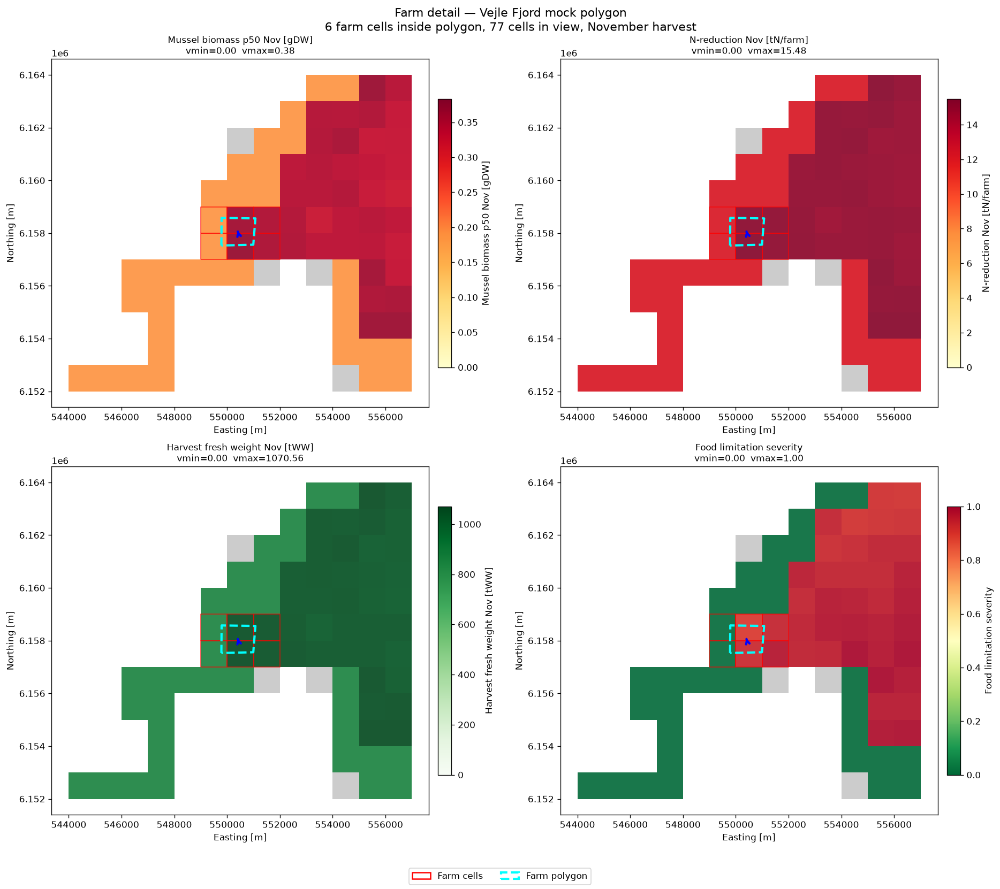

In [16]:
from model.module12_farm import lonlat_to_utm
from config import MOCK_FARM_COORDS_LONLAT
import matplotlib.patches as mpatches
from shapely.geometry import box

# ── Farm polygon and view area ─────────────────────────────────────────────────
polygon_utm = lonlat_to_utm(MOCK_FARM_COORDS_LONLAT)
minx, miny, maxx, maxy = polygon_utm.bounds
buf = 5000  # 5km buffer
bbox = box(minx-buf, miny-buf, maxx+buf, maxy+buf)

# Clip grid to view area (keep in UTM32N — no CRS conversion)
farm_area   = grid[grid.geometry.intersects(bbox)].copy()
farm_cells  = farm_area[farm_area.geometry.intersects(polygon_utm)].copy()

print(f"View area cells : {len(farm_area):,}")
print(f"Farm cells      : {len(farm_cells)}")

# ── Value ranges from full grid (not local) ───────────────────────────────────
params = [
    ('mbio_p50_11',             'Mussel biomass p50 Nov [gDW]', 'YlOrRd'),
    ('N_red_11',                'N-reduction Nov [tN/farm]',     'YlOrRd'),
    ('harvest_WW_11',           'Harvest fresh weight Nov [tWW]','Greens'),
    ('food_limitation_severity','Food limitation severity',       'RdYlGn_r'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for ax, (col, label, cmap) in zip(axes, params):
    if col not in farm_area.columns:
        ax.set_title(f'{label} — not available')
        continue

    # Colourscale anchored to full domain
    if col == 'food_limitation_severity':
        vmin, vmax = 0.0, 1.0
    else:
        full_vals = grid[col][grid[col] > 0]
        vmin = 0.0
        vmax = float(full_vals.quantile(0.98))



        # ── Plot in UTM32N (no CRS conversion) ──────────────────────────────────
    # Excluded cells — distinct grey
    excl  = farm_area[farm_area['excluded']]
    avail = farm_area[~farm_area['excluded']]

    if not excl.empty:
        excl.plot(ax=ax, color='#cccccc', edgecolor='none')

    # Available cells — colourscale
    avail.plot(
        column=col, ax=ax,
        cmap=cmap, vmin=vmin, vmax=vmax,
        legend=True,
        legend_kwds={'label': label, 'shrink': 0.7, 'pad': 0.02},
        missing_kwds={'color': 'lightgrey'},
        alpha=0.9,
    )

    # Farm cells — thick outline
    farm_cells.boundary.plot(ax=ax, color='red', linewidth=1.0, alpha=0.7)

    # Polygon outline
    poly_gdf = gpd.GeoDataFrame(geometry=[polygon_utm], crs='EPSG:32632')
    poly_gdf.boundary.plot(ax=ax, color='cyan', linewidth=2.5, linestyle='--')

    # Current direction arrow
    if 'uo_11' in farm_cells.columns and not farm_cells.empty:
        uo = farm_cells['uo_11'].mean()
        vo = farm_cells['vo_11'].mean()
        cx = polygon_utm.centroid.x
        cy = polygon_utm.centroid.y
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        scale = (xmax - xmin) * 0.3  # arrow = 30% of view width at 0.1 m/s
        ax.annotate('',
            xy=(cx + uo*scale*10, cy + vo*scale*10),
            xytext=(cx, cy),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5),
        )
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

    ax.set_title(f'{label}\nvmin={vmin:.2f}  vmax={vmax:.2f}', fontsize=10)
    ax.set_xlabel('Easting [m]')
    ax.set_ylabel('Northing [m]')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(edgecolor='red',  facecolor='none', linewidth=1.5, label='Farm cells'),
    mpatches.Patch(edgecolor='cyan', facecolor='none', linewidth=2.5,
                   linestyle='dashed', label='Farm polygon'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10)

plt.suptitle(
    f'Farm detail — Vejle Fjord mock polygon\n'
    f'{len(farm_cells)} farm cells inside polygon, {len(farm_area)} cells in view, '
    f'November harvest',
    fontsize=13,
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

View area cells : 77
Farm cells      : 6


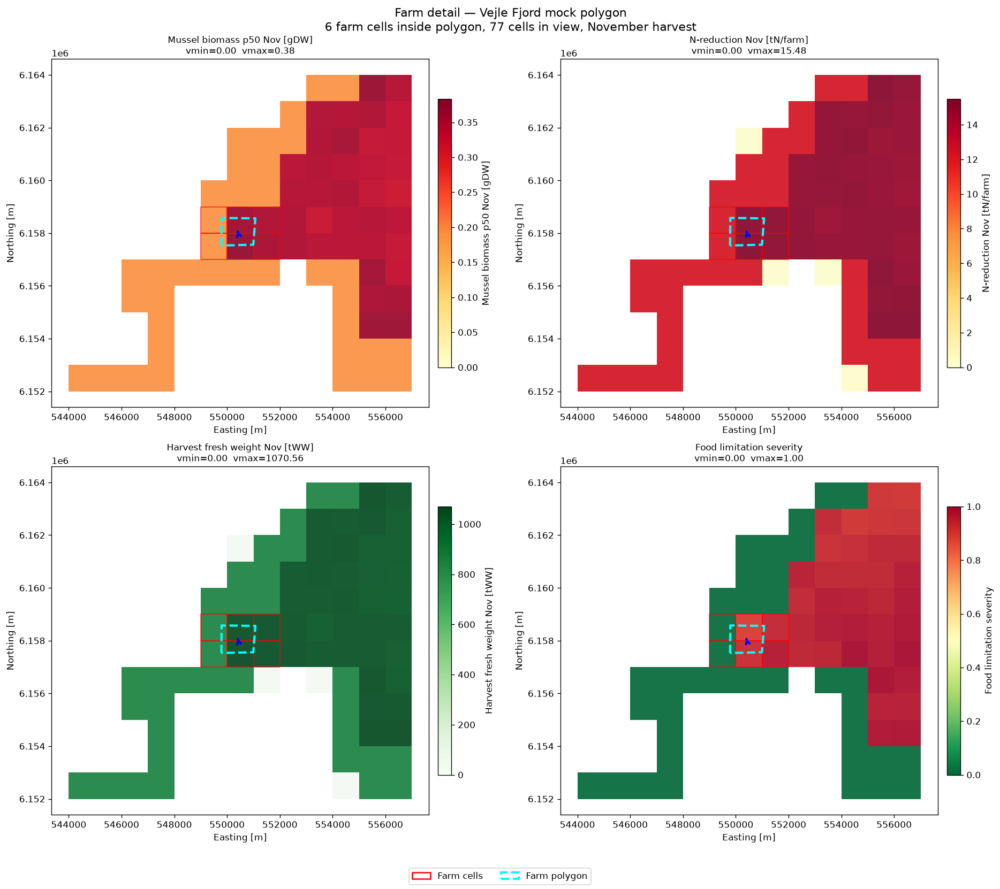

In [17]:
from model.module12_farm import lonlat_to_utm
from config import MOCK_FARM_COORDS_LONLAT
import matplotlib.patches as mpatches
from shapely.geometry import box

# ── Farm polygon and view area ─────────────────────────────────────────────────
polygon_utm = lonlat_to_utm(MOCK_FARM_COORDS_LONLAT)
minx, miny, maxx, maxy = polygon_utm.bounds
buf = 5000  # 5km buffer
bbox = box(minx-buf, miny-buf, maxx+buf, maxy+buf)

# Clip grid to view area (keep in UTM32N — no CRS conversion)
farm_area   = grid[grid.geometry.intersects(bbox)].copy()
farm_cells  = farm_area[farm_area.geometry.intersects(polygon_utm)].copy()

print(f"View area cells : {len(farm_area):,}")
print(f"Farm cells      : {len(farm_cells)}")

# ── Value ranges from full grid (not local) ───────────────────────────────────
params = [
    ('mbio_p50_11',             'Mussel biomass p50 Nov [gDW]', 'YlOrRd'),
    ('N_red_11',                'N-reduction Nov [tN/farm]',     'YlOrRd'),
    ('harvest_WW_11',           'Harvest fresh weight Nov [tWW]','Greens'),
    ('food_limitation_severity','Food limitation severity',       'RdYlGn_r'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for ax, (col, label, cmap) in zip(axes, params):
    if col not in farm_area.columns:
        ax.set_title(f'{label} — not available')
        continue

    # Colourscale anchored to full domain
    if col == 'food_limitation_severity':
        vmin, vmax = 0.0, 1.0
    else:
        full_vals = grid[col][grid[col] > 0]
        vmin = 0.0
        vmax = float(full_vals.quantile(0.98))

    # ── Plot in UTM32N (no CRS conversion) ──────────────────────────────────
    # Background context cells (grey)
    farm_area.plot(ax=ax, color='#e8e8e8', edgecolor='none')

    # Data layer
    farm_area.plot(
        column=col, ax=ax,
        cmap=cmap, vmin=vmin, vmax=vmax,
        legend=True,
        legend_kwds={'label': label, 'shrink': 0.7, 'pad': 0.02},
        missing_kwds={'color': 'lightgrey'},
        alpha=0.9,
    )

    # Farm cells — thick outline
    farm_cells.boundary.plot(ax=ax, color='red', linewidth=1.0, alpha=0.7)

    # Polygon outline
    poly_gdf = gpd.GeoDataFrame(geometry=[polygon_utm], crs='EPSG:32632')
    poly_gdf.boundary.plot(ax=ax, color='cyan', linewidth=2.5, linestyle='--')

    # Current direction arrow
    if 'uo_11' in farm_cells.columns and not farm_cells.empty:
        uo = farm_cells['uo_11'].mean()
        vo = farm_cells['vo_11'].mean()
        cx = polygon_utm.centroid.x
        cy = polygon_utm.centroid.y
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        scale = (xmax - xmin) * 0.3  # arrow = 30% of view width at 0.1 m/s
        ax.annotate('',
            xy=(cx + uo*scale*10, cy + vo*scale*10),
            xytext=(cx, cy),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5),
        )
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

    ax.set_title(f'{label}\nvmin={vmin:.2f}  vmax={vmax:.2f}', fontsize=10)
    ax.set_xlabel('Easting [m]')
    ax.set_ylabel('Northing [m]')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(edgecolor='red',  facecolor='none', linewidth=1.5, label='Farm cells'),
    mpatches.Patch(edgecolor='cyan', facecolor='none', linewidth=2.5,
                   linestyle='dashed', label='Farm polygon'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10)

plt.suptitle(
    f'Farm detail — Vejle Fjord mock polygon\n'
    f'{len(farm_cells)} farm cells inside polygon, {len(farm_area)} cells in view, '
    f'November harvest',
    fontsize=13,
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [ ]:
# # #DEBUG
# # Bare minimum plot — no clim, no basemap, no extras
# fig, ax = plt.subplots(figsize=(10, 8))
# farm_area.plot(column='N_red_11', ax=ax, cmap='YlOrRd', legend=True)
# ax.set_title('N_red_11 bare plot')
# plt.show()
# print(farm_area['N_red_11'].describe())

# print(type(farm_area))
# print(farm_area.crs)
# print('N_red_11 in farm_area:', 'N_red_11' in farm_area.columns)
# print("Farm cells exclusion status:")
# print(farm_cells[['cell_id', 'excluded', 'excl_shallow', 'excl_mpa', 
#                    'excl_military', 'excl_wind_farms', 'excl_cables', 
#                    'excl_pipelines', 'bathymetry_m']].to_string(index=False))

# print(f"\nFarm cells: {len(farm_cells)}")
# print(f"  Excluded : {farm_cells['excluded'].sum()}")
# print(f"  Available: {(~farm_cells['excluded']).sum()}")
# print(f"\nN_red_11 in farm cells:")
# print(farm_cells['N_red_11'].describe())

# surrounding = farm_area[~farm_area.index.isin(farm_cells.index)]
# print(f"Surrounding cells: {len(surrounding)}")
# print(f"\nN_red_11 surrounding:")
# print(surrounding['N_red_11'].describe())
# print(f"\nN_red_11 farm cells:")
# print(farm_cells['N_red_11'].describe())
# print(f"\nBathymetry surrounding:")
# print(surrounding['bathymetry_m'].describe())
# print(f"\nExcluded in surrounding: {surrounding['excluded'].sum()} / {len(surrounding)}")

# print("Zero N_red cells in view area:")
# zero_cells = farm_area[farm_area['N_red_11'] == 0]
# print(f"  Count: {len(zero_cells)}")
# print(zero_cells[['cell_id','excluded','excl_shallow','bathymetry_m','rdep','N_red_11']].to_string(index=False))